<a href="https://colab.research.google.com/github/yeonji200522-oss/Hands-on-Machine-Learning/blob/main/RF_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
원본 데이터 shape: (162375, 41)


,Address_Full,Gu_Name,Dong,Jibun,Apartment_Name,Price_String,Size_m2,Floor,Construction_Year,Year_Sold,...,Log_Dist_Water,Parking_per_Household,Young Population,Median age,Old Population,Pop. Density,Sex_ratio,Price_per_m2,Log_Price_per_m2,Population
0,서울특별시 종로구 숭인동 296-19,종로구,숭인동,296-19,삼전솔하임2차,10200,15.000,7,2012,2022,...,6.251133,0.214286,0.051709,0.765055,0.183237,26741.379325,0.980859,6.800000e+06,15.732433,15510
1,서울특별시 종로구 명륜2가 4,종로구,명륜2가,4,아남1,118000,84.900,18,1995,2022,...,6.769297,0.997706,0.071774,0.762895,0.165331,14591.964300,0.927700,1.389870e+07,16.447306,16343
2,서울특별시 종로구 연건동 195-10,종로구,연건동,195-10,이화에수풀,19500,16.980,7,2014,2022,...,6.528250,0.300000,0.052755,0.758793,0.188452,9258.974400,0.902500,1.148410e+07,16.256474,7222
3,서울특별시 종로구 내수동 72,종로구,내수동,72,경희궁의아침3단지,200000,150.480,3,2004,2022,...,6.984716,2.100000,0.095304,0.716547,0.188148,7600.813000,0.812200,1.329080e+07,16.402583,9349
4,서울특별시 종로구 효제동 65-2,종로구,효제동,1965-02-01 00:00:00,포레스트힐시티,19000,16.672,6,2017,2022,...,6.301153,0.611842,0.034897,0.757492,0.207610,8453.333300,1.146400,1.139635e+07,16.248804,5072



사용 변수:
['Population', 'Sex_ratio', 'Pop. Density', 'Old Population', 'Median age', 'Young Population', 'Parking_per_Household', 'Log_Dist_Water', 'Log_Dist_Green', 'Log_Dist_Subway', 'Dist_CBD', 'max_floor', 'heating_dummy', 'num_of_people', 'Bus_Stop', 'High_School_Count', 'Floor', 'Size_m2', 'Construction_Year', 'Spring', 'Fall', 'Winter']

최종 데이터 shape: (162375, 45)

연도별 개수:
Year_Sold
2022    10579
2023    31071
2024    50697
2025    70028
Name: count, dtype: int64

==================== 2022년 분석 시작 ====================
2022년 데이터 수: 10579


,Year,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_N,Test_N
0,2022,RF,0.981058,0.869589,0.061905,0.165327,7405,3174


2022년 SHAP 데이터 크기: (3174, 22)


,Feature,MeanAbsSHAP
0,num_of_people,0.158803
1,Young Population,0.146405
2,Population,0.067796
3,Construction_Year,0.062857
4,Old Population,0.051856
5,Size_m2,0.039163
6,Sex_ratio,0.022987
7,Bus_Stop,0.018806
8,Median age,0.018481
9,Parking_per_Household,0.017298



[2022년 RF SHAP Summary Plot - Beeswarm]


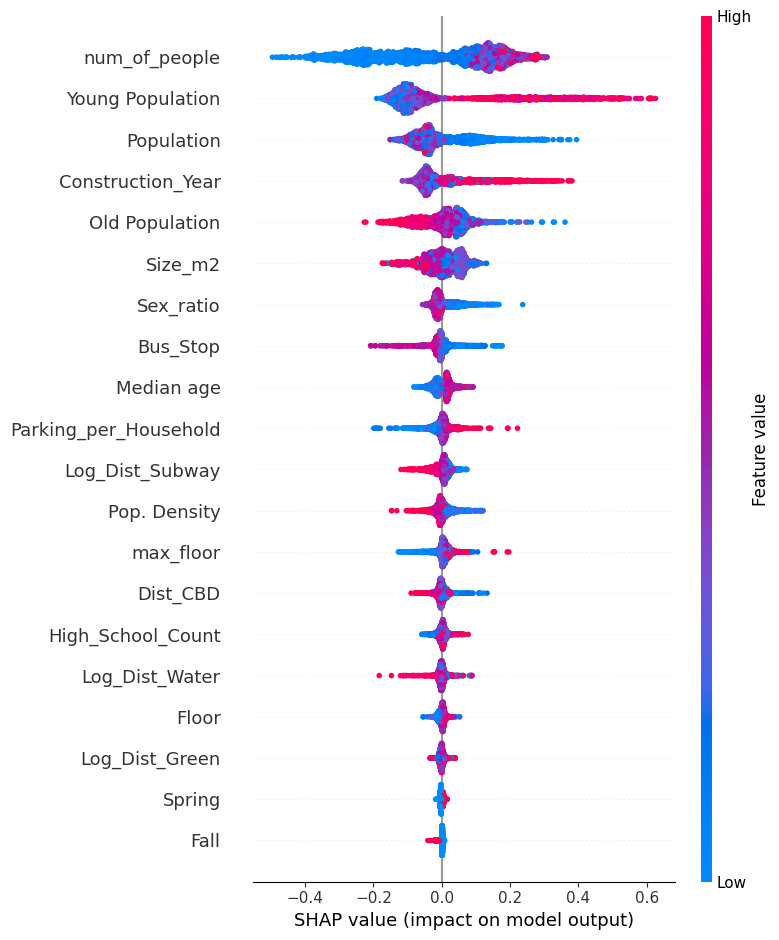


[2022년 RF SHAP Summary Plot - Bar]


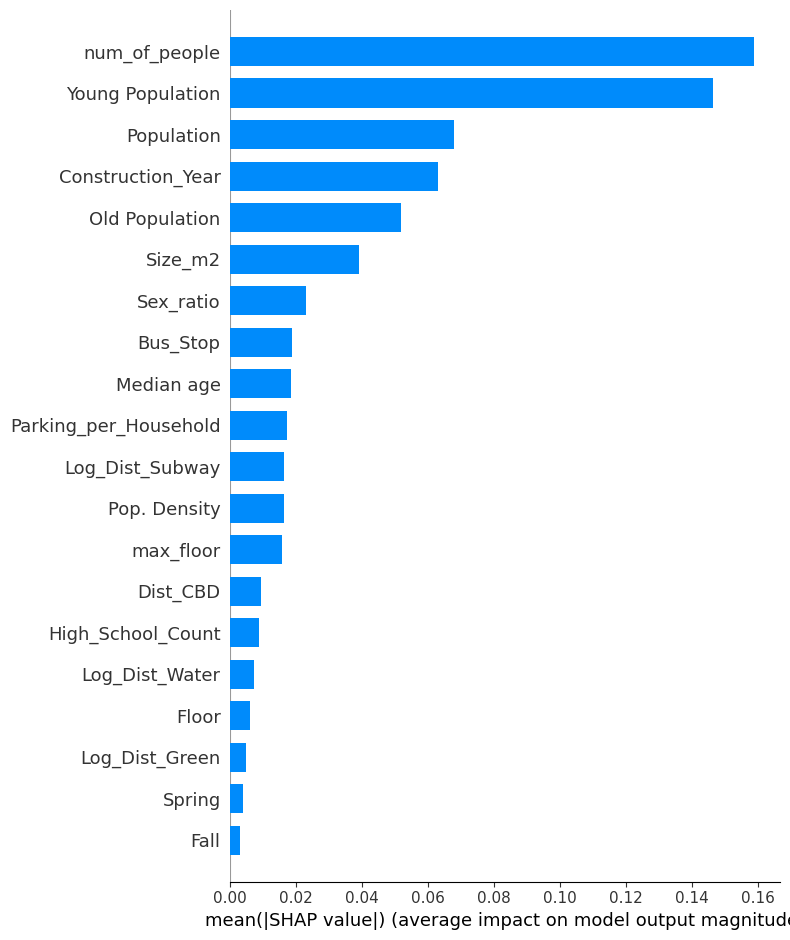


==================== 2023년 분석 시작 ====================
2023년 데이터 수: 31071


,Year,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_N,Test_N
0,2023,RF,0.991831,0.949559,0.039011,0.097342,21749,9322


2023년 SHAP 데이터 크기: (9322, 22)


,Feature,MeanAbsSHAP
0,Young Population,0.154353
1,num_of_people,0.087399
2,Old Population,0.076867
3,Construction_Year,0.064159
4,Size_m2,0.056958
5,Population,0.045412
6,Bus_Stop,0.030147
7,Log_Dist_Subway,0.027602
8,Pop. Density,0.022027
9,max_floor,0.019148



[2023년 RF SHAP Summary Plot - Beeswarm]


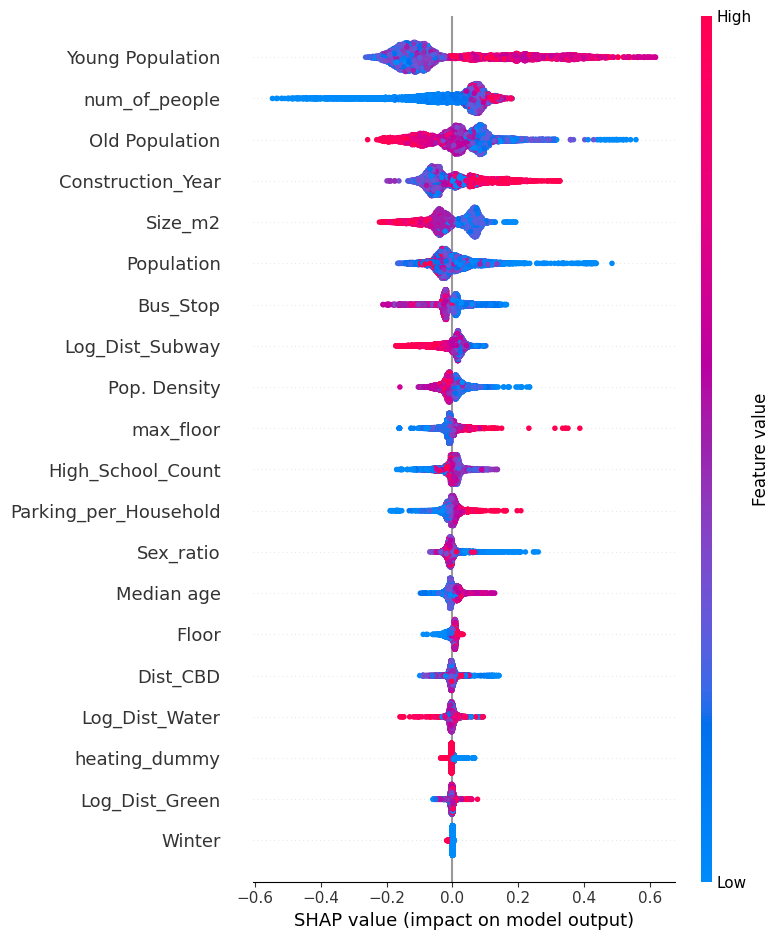


[2023년 RF SHAP Summary Plot - Bar]


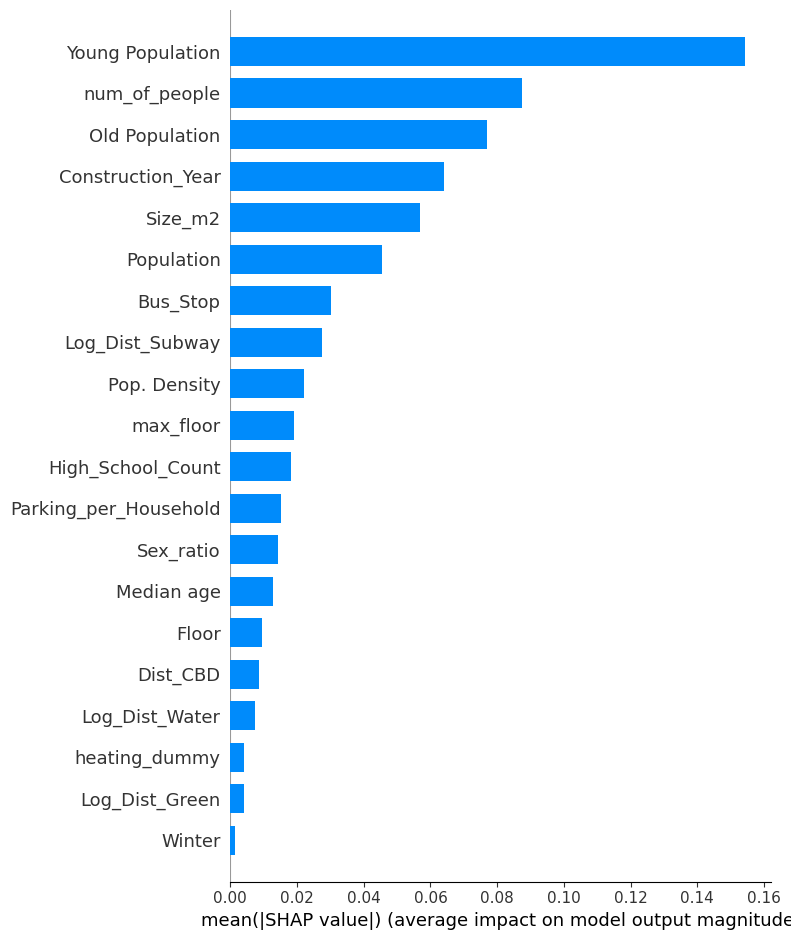


==================== 2024년 분석 시작 ====================
2024년 데이터 수: 50697


,Year,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_N,Test_N
0,2024,RF,0.995,0.967825,0.032387,0.081658,35487,15210


2024년 SHAP 데이터 크기: (15210, 22)


In [ ]:
# ============================================================
# 0. 설치
# ============================================================
!pip install shap openpyxl -q

# ============================================================
# 1. 라이브러리
# ============================================================
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from IPython.display import display

shap.initjs()

# ============================================================
# 2. Google Drive 연결
# ============================================================
drive.mount('/content/drive', force_remount=True)

# ============================================================
# 3. 데이터 불러오기
# ============================================================
file_path = '/content/drive/MyDrive/!Seoul_Aprtment_FINAL.xlsx'
df_raw = pd.read_excel(file_path)

print("원본 데이터 shape:", df_raw.shape)
display(df_raw.head())

# ============================================================
# 4. 전처리
# ============================================================
def prepare_df(df_input):
    df = df_input.copy()

    # heating 더미
    if "heating" in df.columns:
        df["heating_dummy"] = df["heating"].astype(str).apply(
            lambda x: 1 if ("도시가스" in x or x.strip() == "1") else 0
        )

    # 연도별로 나누기
    if "Year_Sold" in df.columns:
        df["Year_Sold"] = pd.to_numeric(df["Year_Sold"], errors="coerce")

    elif "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Year_Sold"] = df["Date"].dt.year
        df["Month_Sold"] = df["Date"].dt.month

    elif "Sold_Date" in df.columns:
        df["Sold_Date"] = pd.to_datetime(df["Sold_Date"], errors="coerce")
        df["Year_Sold"] = df["Sold_Date"].dt.year
        df["Month_Sold"] = df["Sold_Date"].dt.month

    # 계절 더미
    if "Month_Sold" in df.columns:
        m = pd.to_numeric(df["Month_Sold"], errors="coerce")
        df["Spring"] = m.isin([3, 4, 5]).astype(int)
        df["Fall"]   = m.isin([9, 10, 11]).astype(int)
        df["Winter"] = m.isin([12, 1, 2]).astype(int)

    # 수치형 변환
    num_cols = [
        "Population","Sex_ratio","Pop. Density",
        "Old Population","Median age","Young Population",
        "Parking_per_Household",
        "Log_Dist_Water","Log_Dist_Green","Log_Dist_Subway",
        "Dist_CBD","max_floor","num_of_people",
        "Bus_Stop","High_School_Count",
        "Floor","Size_m2","Construction_Year",
        "Log_Price_per_m2","Year_Sold"
    ]

    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

df = prepare_df(df_raw)

# # ============================================================
# 5. 변수 설정
# ============================================================
target = "Log_Price_per_m2"

features = [
    "Population",
    "Sex_ratio",
    "Pop. Density",
    "Old Population",
    "Median age",
    "Young Population",
    "Parking_per_Household",
    "Log_Dist_Water",
    "Log_Dist_Green",
    "Log_Dist_Subway",
    "Dist_CBD",
    "max_floor",
    "heating_dummy",
    "num_of_people",
    "Bus_Stop",
    "High_School_Count",
    "Floor",
    "Size_m2",
    "Construction_Year",
    "Spring",
    "Fall",
    "Winter"
]

features = [c for c in features if c in df.columns]

print("\n사용 변수:")
print(features)

# 연도 컬럼 존재 확인
if "Year_Sold" not in df.columns:
    raise ValueError("Year_Sold 컬럼이 없습니다. Date 또는 Sold_Date에서 연도를 추출하도록 확인하세요.")

# 결측 제거
df_model = df.dropna(subset=features + [target, "Year_Sold"]).copy().reset_index(drop=True)

print("\n최종 데이터 shape:", df_model.shape)
print("\n연도별 개수:")
print(df_model["Year_Sold"].value_counts().sort_index())

# ============================================================
# 6~12. 연도별 RF + SHAP
# ============================================================
years = [2022, 2023, 2024]

all_perf = []

output_path = '/content/drive/MyDrive/RF_SHAP_By_Year.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    for yr in years:
        print(f"\n==================== {yr}년 분석 시작 ====================")

        df_year = df_model[df_model["Year_Sold"] == yr].copy().reset_index(drop=True)

        print(f"{yr}년 데이터 수:", len(df_year))

        if len(df_year) < 10:
            print(f"{yr}년 데이터가 너무 적어서 건너뜁니다.")
            continue

        X = df_year[features]
        y = df_year[target]

        # train / test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )

        # RF 학습
        rf = RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # 성능 평가
        pred_train = rf.predict(X_train)
        pred_test = rf.predict(X_test)

        rf_result = pd.DataFrame([{
            "Year": yr,
            "Model": "RF",
            "Train_R2": r2_score(y_train, pred_train),
            "Test_R2": r2_score(y_test, pred_test),
            "Train_RMSE": np.sqrt(mean_squared_error(y_train, pred_train)),
            "Test_RMSE": np.sqrt(mean_squared_error(y_test, pred_test)),
            "Train_N": len(X_train),
            "Test_N": len(X_test)
        }])

        display(rf_result)
        all_perf.append(rf_result)

        # SHAP: 테스트셋 전체 사용
        X_shap = X_test.copy()
        print(f"{yr}년 SHAP 데이터 크기:", X_shap.shape)

        rf_explainer = shap.TreeExplainer(rf)
        rf_shap_values = rf_explainer.shap_values(X_shap)

        rf_importance = pd.DataFrame({
            "Feature": X_shap.columns,
            "MeanAbsSHAP": np.abs(rf_shap_values).mean(axis=0)
        }).sort_values(by="MeanAbsSHAP", ascending=False).reset_index(drop=True)

        display(rf_importance)

        # 엑셀 저장
        rf_result.to_excel(writer, sheet_name=f'{yr}_Perf', index=False)
        rf_importance.to_excel(writer, sheet_name=f'{yr}_SHAP', index=False)

        # SHAP plot
        print(f"\n[{yr}년 RF SHAP Summary Plot - Beeswarm]")
        shap.summary_plot(rf_shap_values, X_shap)

        print(f"\n[{yr}년 RF SHAP Summary Plot - Bar]")
        shap.summary_plot(rf_shap_values, X_shap, plot_type="bar")

    # 전체 성능표 저장
    if len(all_perf) > 0:
        perf_all_df = pd.concat(all_perf, axis=0).reset_index(drop=True)
        perf_all_df.to_excel(writer, sheet_name='All_Performance', index=False)

print("\n저장 완료:", output_path)